# Data Extraction and Preparation for SGC plot QC validation project
By Muhammad Erico Ricardo

# 1. Introduction
Pada kali ini kita akan melakukan tatacara penarikan data dan juga manual validation yang mana datanya kedepannya akan digunakan untuk SGC plot QC Validation Project yang mana adalah sistem klasifikasi yang kedepannya akan menggunakan machine learning.

# 2. Extract Data From ODA Database
Gunakan query dibawah untuk mengambil data dari database, untuk kriterianya sendiri adalah :
1. Data yang diambil sudah dicheck manual oleh user oda.
2. Akurasi tidak 0
3. GPS Coordinate tidak 0.0.0.0
4. Data yang diambil adalah data season 2025, karena per 14-mei-2026, data petak yang benar yang pasti sudah ada di database adalah yang season 2025.
5. Shape polygon tidak Null.

In [1]:
# SELECT 
#     a.*, 
#     gp.SHAPE
# FROM (
#     (SELECT 
#         'basal' AS Kegiatan,
#         tqb.OCCODE, tqb.TRANSNO, tqb.BLOCKCODE, tqb.SUBBLOCKCODE,
#         s1.GPSCOORD AS Koordinat_sample_1, 
#         s2.GPSCOORD AS Koordinat_sample_2, 
#         s3.GPSCOORD AS Koordinat_sample_3,
#         tqb.AKURASI, tqb.JUMLAH_SATELIT, tqb.IS_VALID_SAMPLING, tqb.SCANON, tqb.VALIDATION_NOTE, tqb.ISCHECK
#     FROM tr_qc_inspeksi_basal tqb
#     LEFT JOIN tr_qc_inspeksi_basal_detail s1 
#         ON tqb.TRANSNO = s1.TRANSNO AND s1.SAMPLEID = 1
#     LEFT JOIN tr_qc_inspeksi_basal_detail s2 
#         ON tqb.TRANSNO = s2.TRANSNO AND s2.SAMPLEID = 2
#     LEFT JOIN tr_qc_inspeksi_basal_detail s3 
#         ON tqb.TRANSNO = s3.TRANSNO AND s3.SAMPLEID = 3
#     WHERE tqb.ISCHECK != 0
#       AND tqb.AKURASI != 0
#       AND tqb.SCANON >= '2025-05-01'
#       AND tqb.SCANON < '2025-12-01'
#       AND COALESCE(s1.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s2.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s3.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#     ORDER BY tqb.SCANON DESC 
#     LIMIT 200)

#     UNION ALL

#     (SELECT 
#         'Brushing' AS Kegiatan,
#         tqb.OCCODE, tqb.TRANSNO, tqb.BLOCKCODE, tqb.SUBBLOCKCODE,
#         s1.GPSCOORD AS Koordinat_sample_1, 
#         s2.GPSCOORD AS Koordinat_sample_2, 
#         s3.GPSCOORD AS Koordinat_sample_3,
#         tqb.AKURASI, tqb.JUMLAH_SATELIT, tqb.IS_VALID_SAMPLING, tqb.SCANON, tqb.VALIDATION_NOTE, tqb.ISCHECK
#     FROM tr_qc_inspeksi_brushing tqb
#     LEFT JOIN tr_qc_inspeksi_brushing_detail s1 
#         ON tqb.TRANSNO = s1.TRANSNO AND s1.SAMPLEID = 1
#     LEFT JOIN tr_qc_inspeksi_brushing_detail s2 
#         ON tqb.TRANSNO = s2.TRANSNO AND s2.SAMPLEID = 2
#     LEFT JOIN tr_qc_inspeksi_brushing_detail s3 
#         ON tqb.TRANSNO = s3.TRANSNO AND s3.SAMPLEID = 3
#     WHERE tqb.ISCHECK != 0
#       AND tqb.AKURASI != 0
#       AND tqb.SCANON >= '2025-05-01'
#       AND tqb.SCANON < '2025-12-01'
#       AND COALESCE(s1.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s2.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s3.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#     ORDER BY tqb.SCANON DESC 
#     LIMIT 200)

#     UNION ALL

#     (SELECT 
#         'Ecer' AS Kegiatan,
#         tqb.OCCODE, tqb.TRANSNO, tqb.BLOCKCODE, tqb.SUBBLOCKCODE,
#         s1.GPSCOORD AS Koordinat_sample_1, 
#         s2.GPSCOORD AS Koordinat_sample_2, 
#         s3.GPSCOORD AS Koordinat_sample_3,
#         tqb.AKURASI, tqb.JUMLAH_SATELIT, tqb.IS_VALID_SAMPLING, tqb.SCANON, tqb.VALIDATION_NOTE, tqb.ISCHECK
#     FROM tr_qc_inspeksi_ecer tqb
#     LEFT JOIN tr_qc_inspeksi_ecer_detail s1 
#         ON tqb.TRANSNO = s1.TRANSNO AND s1.SAMPLEID = 1
#     LEFT JOIN tr_qc_inspeksi_ecer_detail s2 
#         ON tqb.TRANSNO = s2.TRANSNO AND s2.SAMPLEID = 2
#     LEFT JOIN tr_qc_inspeksi_ecer_detail s3 
#         ON tqb.TRANSNO = s3.TRANSNO AND s3.SAMPLEID = 3
#     WHERE tqb.ISCHECK != 0
#       AND tqb.AKURASI != 0
#       AND tqb.SCANON >= '2025-05-01'
#       AND tqb.SCANON < '2025-12-01'
#       AND COALESCE(s1.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s2.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s3.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#     ORDER BY tqb.SCANON DESC 
#     LIMIT 200)

#     UNION ALL

#     (SELECT 
#         'Cover' AS Kegiatan,
#         tqb.OCCODE, tqb.TRANSNO, tqb.BLOCKCODE, tqb.SUBBLOCKCODE,
#         s1.GPSCOORD AS Koordinat_sample_1, 
#         s2.GPSCOORD AS Koordinat_sample_2, 
#         s3.GPSCOORD AS Koordinat_sample_3,
#         tqb.AKURASI, tqb.JUMLAH_SATELIT, tqb.IS_VALID_SAMPLING, tqb.SCANON, tqb.VALIDATION_NOTE, tqb.ISCHECK
#     FROM tr_qc_inspeksi_cover tqb
#     LEFT JOIN tr_qc_inspeksi_cover_detail s1 
#         ON tqb.TRANSNO = s1.TRANSNO AND s1.SAMPLEID = 1
#     LEFT JOIN tr_qc_inspeksi_cover_detail s2 
#         ON tqb.TRANSNO = s2.TRANSNO AND s2.SAMPLEID = 2
#     LEFT JOIN tr_qc_inspeksi_cover_detail s3 
#         ON tqb.TRANSNO = s3.TRANSNO AND s3.SAMPLEID = 3
#     WHERE tqb.ISCHECK != 0
#       AND tqb.AKURASI != 0
#       AND tqb.SCANON >= '2025-05-01'
#       AND tqb.SCANON < '2025-12-01'
#       AND COALESCE(s1.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s2.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s3.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#     ORDER BY tqb.SCANON DESC 
#     LIMIT 200)

#     UNION ALL

#     (SELECT 
#         'Drop' AS Kegiatan,
#         tqb.OCCODE, tqb.TRANSNO, tqb.BLOCKCODE, tqb.SUBBLOCKCODE,
#         s1.GPSCOORD AS Koordinat_sample_1, 
#         s2.GPSCOORD AS Koordinat_sample_2, 
#         s3.GPSCOORD AS Koordinat_sample_3,
#         tqb.AKURASI, tqb.JUMLAH_SATELIT, tqb.IS_VALID_SAMPLING, tqb.SCANON, tqb.VALIDATION_NOTE, tqb.ISCHECK
#     FROM tr_qc_inspeksi_drop tqb
#     LEFT JOIN tr_qc_inspeksi_drop_detail s1 
#         ON tqb.TRANSNO = s1.TRANSNO AND s1.SAMPLEID = 1
#     LEFT JOIN tr_qc_inspeksi_drop_detail s2 
#         ON tqb.TRANSNO = s2.TRANSNO AND s2.SAMPLEID = 2
#     LEFT JOIN tr_qc_inspeksi_drop_detail s3 
#         ON tqb.TRANSNO = s3.TRANSNO AND s3.SAMPLEID = 3
#     WHERE tqb.ISCHECK != 0
#       AND tqb.AKURASI != 0
#       AND tqb.SCANON >= '2025-05-01'
#       AND tqb.SCANON < '2025-12-01'
#       AND COALESCE(s1.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s2.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s3.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#     ORDER BY tqb.SCANON DESC 
#     LIMIT 200)

#     UNION ALL

#     (SELECT 
#         'Harrowing' AS Kegiatan,
#         tqb.OCCODE, tqb.TRANSNO, tqb.BLOCKCODE, tqb.SUBBLOCKCODE,
#         s1.GPSCOORD AS Koordinat_sample_1, 
#         s2.GPSCOORD AS Koordinat_sample_2, 
#         s3.GPSCOORD AS Koordinat_sample_3,
#         tqb.AKURASI, tqb.JUMLAH_SATELIT, tqb.IS_VALID_SAMPLING, tqb.SCANON, tqb.VALIDATION_NOTE, tqb.ISCHECK
#     FROM tr_qc_inspeksi_harrowing tqb
#     LEFT JOIN tr_qc_inspeksi_harrowing_detail s1 
#         ON tqb.TRANSNO = s1.TRANSNO AND s1.SAMPLEID = 1
#     LEFT JOIN tr_qc_inspeksi_harrowing_detail s2 
#         ON tqb.TRANSNO = s2.TRANSNO AND s2.SAMPLEID = 2
#     LEFT JOIN tr_qc_inspeksi_harrowing_detail s3 
#         ON tqb.TRANSNO = s3.TRANSNO AND s3.SAMPLEID = 3
#     WHERE tqb.ISCHECK != 0
#       AND tqb.AKURASI != 0
#       AND tqb.SCANON >= '2025-05-01'
#       AND tqb.SCANON < '2025-12-01'
#       AND COALESCE(s1.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s2.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s3.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#     ORDER BY tqb.SCANON DESC 
#     LIMIT 200)

#     UNION ALL

#     (SELECT 
#         'Keremahan' AS Kegiatan,
#         tqb.OCCODE, tqb.TRANSNO, tqb.BLOCKCODE, tqb.SUBBLOCKCODE,
#         s1.GPSCOORD AS Koordinat_sample_1, 
#         s2.GPSCOORD AS Koordinat_sample_2, 
#         s3.GPSCOORD AS Koordinat_sample_3,
#         tqb.AKURASI, tqb.JUMLAH_SATELIT, tqb.IS_VALID_SAMPLING, tqb.SCANON, tqb.VALIDATION_NOTE, tqb.ISCHECK
#     FROM tr_qc_inspeksi_keremahan tqb
#     LEFT JOIN tr_qc_inspeksi_keremahan_detail s1 
#         ON tqb.TRANSNO = s1.TRANSNO AND s1.SAMPLEID = 1
#     LEFT JOIN tr_qc_inspeksi_keremahan_detail s2 
#         ON tqb.TRANSNO = s2.TRANSNO AND s2.SAMPLEID = 2
#     LEFT JOIN tr_qc_inspeksi_keremahan_detail s3 
#         ON tqb.TRANSNO = s3.TRANSNO AND s3.SAMPLEID = 3
#     WHERE tqb.ISCHECK != 0
#       AND tqb.AKURASI != 0
#       AND tqb.SCANON >= '2025-05-01'
#       AND tqb.SCANON < '2025-12-01'
#       AND COALESCE(s1.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s2.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s3.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#     ORDER BY tqb.SCANON DESC 
#     LIMIT 200)

#     UNION ALL

#     (SELECT 
#         'Pre-Emergence' AS Kegiatan,
#         tqb.OCCODE, tqb.TRANSNO, tqb.BLOCKCODE, tqb.SUBBLOCKCODE,
#         s1.GPSCOORD AS Koordinat_sample_1, 
#         s2.GPSCOORD AS Koordinat_sample_2, 
#         s3.GPSCOORD AS Koordinat_sample_3,
#         tqb.AKURASI, tqb.JUMLAH_SATELIT, tqb.IS_VALID_SAMPLING, tqb.SCANON, tqb.VALIDATION_NOTE, tqb.ISCHECK
#     FROM tr_qc_inspeksi_pre_emergence tqb
#     LEFT JOIN tr_qc_inspeksi_pre_emergence_detail s1 
#         ON tqb.TRANSNO = s1.TRANSNO AND s1.SAMPLEID = 1
#     LEFT JOIN tr_qc_inspeksi_pre_emergence_detail s2 
#         ON tqb.TRANSNO = s2.TRANSNO AND s2.SAMPLEID = 2
#     LEFT JOIN tr_qc_inspeksi_pre_emergence_detail s3 
#         ON tqb.TRANSNO = s3.TRANSNO AND s3.SAMPLEID = 3
#     WHERE tqb.ISCHECK != 0
#       AND tqb.AKURASI != 0
#       AND tqb.SCANON >= '2025-05-01'
#       AND tqb.SCANON < '2025-12-01'
#       AND COALESCE(s1.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s2.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#       AND COALESCE(s3.GPSCOORD, '0.0,0.0') != '0.0,0.0'
#     ORDER BY tqb.SCANON DESC 
#     LIMIT 200)
# ) AS a
# LEFT JOIN gis_petak gp 
#     ON gp.no_petak = a.SUBBLOCKCODE
# WHERE gp.SHAPE is not null ;

Lalu export ke csv dan buka di project ini.

# 3. Data Preparation

## 3.1 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import os
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point


## 3.2 Data Loading

In [3]:
Data = pd.read_csv('Plot Validation Project.csv')

In [4]:
Data.head()

,Kegiatan,OCCODE,TRANSNO,BLOCKCODE,SUBBLOCKCODE,Koordinat_sample_1,Koordinat_sample_2,Koordinat_sample_3,AKURASI,JUMLAH_SATELIT,IS_VALID_SAMPLING,SCANON,VALIDATION_NOTE,ISCHECK,SHAPE
0,basal,G,Q09GS-GH-131025-002,TU3/17,167TU027,"-4.53715181350708,105.56767272949219","-4.537172794342041,105.56744384765625","-4.5371856689453125,105.56736755371094",3.000,40.0,0,2025-10-13 12:05:09,"Status: Tidak Valid, Sudut sample 1 ke 2: 264....",1,"POLYGON ((105.567004036276 -4.53644686341185, ..."
1,basal,G,Q09GS-GH-131025-001,TU3/17,167TU028,"-4.53695821762085,105.56781768798828","-4.53669548034668,105.5677719116211","-4.5365166664123535,105.5677490234375",1.283,41.0,1,2025-10-13 11:58:30,"Status: Tidak Valid, Sudut sample 1 ke 2: 350....",1,"POLYGON ((105.567034032358 -4.53638705918652, ..."
2,Brushing,G,Q07GF-GQ-161025-003,TU2/16,152TU011,"-4.551975250244141,105.55307006835938","-4.552508354187012,105.55255126953125","-4.552672386169434,105.55240631103516",3.000,27.0,1,2025-10-16 12:01:38,Status: Sample berada diluar petak,1,"POLYGON ((105.554106975476 -4.55282359968282, ..."
3,Brushing,G,Q07GF-GQ-161025-002,TU2/16,152TU013,"-4.551111698150635,105.5523452758789","-4.551556587219238,105.55339050292969","-4.551681041717529,105.55374145507812",3.000,25.0,1,2025-10-16 11:53:45,Status: Sample berada diluar petak,1,"POLYGON ((105.554217760699 -4.55184103728126, ..."
4,basal,G,Q09GF-GQ-101125-005,TU2/16,153TU020,"-4.543455123901367,105.55538940429688","-4.543529987335205,105.55443572998047","-4.543468952178955,105.553955078125",2.757,26.0,1,2025-11-10 11:13:10,"Status: Tidak Valid, Sudut sample 1 ke 2: 265....",1,"POLYGON ((105.553649230401 -4.54335163842276, ..."


## 3.3 Coordinate Data Overview

In [5]:
# See Coordinates Data
Data["Koordinat_sample_1"].head()


0     -4.53715181350708,105.56767272949219
1     -4.53695821762085,105.56781768798828
2    -4.551975250244141,105.55307006835938
3     -4.551111698150635,105.5523452758789
4    -4.543455123901367,105.55538940429688
Name: Koordinat_sample_1, dtype: object

In [6]:
Data["Koordinat_sample_2"].head()


0    -4.537172794342041,105.56744384765625
1      -4.53669548034668,105.5677719116211
2    -4.552508354187012,105.55255126953125
3    -4.551556587219238,105.55339050292969
4    -4.543529987335205,105.55443572998047
Name: Koordinat_sample_2, dtype: object

In [7]:
Data["Koordinat_sample_3"].head()

0    -4.5371856689453125,105.56736755371094
1     -4.5365166664123535,105.5677490234375
2     -4.552672386169434,105.55240631103516
3     -4.551681041717529,105.55374145507812
4       -4.543468952178955,105.553955078125
Name: Koordinat_sample_3, dtype: object

Semua koordinatnya memilliki struktur [ Latitude , Longirude], maka kita akan pisahkan.

In [8]:
# Devide data Koordinat_sample 1,2, 3 to Longitude and Latitude
Data[['Latitude_1', 'Longitude_1']] = Data['Koordinat_sample_1'].str.split(',', expand=True)
Data[['Latitude_2', 'Longitude_2']] = Data['Koordinat_sample_2'].str.split(',', expand=True)
Data[['Latitude_3', 'Longitude_3']] = Data['Koordinat_sample_3'].str.split(',', expand=True)
# Convert Longitude and Latitude to numeric
Data['Longitude_1'] = pd.to_numeric(Data['Longitude_1'], errors='coerce')
Data['Latitude_1'] = pd.to_numeric(Data['Latitude_1'], errors='coerce')
Data['Longitude_2'] = pd.to_numeric(Data['Longitude_2'], errors='coerce')
Data['Latitude_2'] = pd.to_numeric(Data['Latitude_2'], errors='coerce')
Data['Longitude_3'] = pd.to_numeric(Data['Longitude_3'], errors='coerce')
Data['Latitude_3'] = pd.to_numeric(Data['Latitude_3'], errors='coerce')
# Drop original Koordinat_sample columns
Data.drop(['Koordinat_sample_1', 'Koordinat_sample_2', 'Koordinat_sample_3'], axis=1, inplace=True)


## 3.4 Akurasi Data Overview

In [9]:
# See the summary statistics of the data
Data['AKURASI'].describe()

count    1369.000000
mean        7.750944
std        90.633630
min         0.404756
25%         1.350000
50%         2.083000
75%         3.000000
max      2799.999000
Name: AKURASI, dtype: float64

Untuk akurasi ini berdasarkan tim eksi dapat dibagi menjadi :
- good jika < 25 
- Medium jika > 25 dan < 50
- Weak jika > 50

## 3.5 Number of Satelite Overview

In [10]:
# See the summary statistics of the data
Data['JUMLAH_SATELIT'].describe()

count    1369.000000
mean       27.987582
std        12.263636
min         0.000000
25%        27.000000
50%        33.000000
75%        35.000000
max        43.000000
Name: JUMLAH_SATELIT, dtype: float64

Untuk Number of Satelite ini berdasarkan tim eksi dapat dibagi menjadi :
- Good jika > 10
- Medium Jika 4 - 10
- Weak Jika < 4

# 4. Feature Engineering 

In [11]:
# 1. Konversi SHAPE & Proyeksi Meter
Data['geometry'] = Data['SHAPE'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(Data, geometry='geometry', crs="EPSG:4326")
gdf_meter = gdf.to_crs(epsg=32748)
centroids_meter = gdf_meter.geometry.centroid

# --- FUNGSI HELPER ---
def get_points_meter(df, lat_col, lon_col):
    geom = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
    return gpd.GeoDataFrame(geometry=geom, crs="EPSG:4326", index=df.index).to_crs(epsg=32748)

def calculate_angle(p1, p2):
    return np.degrees(np.arctan2(p2.y - p1.y, p2.x - p1.x))

# 2. Proses Ketiga Titik Sampling
points_1 = get_points_meter(gdf, 'Latitude_1', 'Longitude_1')
points_2 = get_points_meter(gdf, 'Latitude_2', 'Longitude_2')
points_3 = get_points_meter(gdf, 'Latitude_3', 'Longitude_3')

# --- FEATURE ENGINEERING MULTI-SAMPLE ---

# A. Status 'Inside' untuk tiap titik
gdf['in_1'] = points_1.within(gdf_meter.geometry).astype(int)
gdf['in_2'] = points_2.within(gdf_meter.geometry).astype(int)
gdf['in_3'] = points_3.within(gdf_meter.geometry).astype(int)

# Fitur Krusial: Apakah semua titik di dalam? (Logika AND)
gdf['all_inside'] = ((gdf['in_1'] == 1) & (gdf['in_2'] == 1) & (gdf['in_3'] == 1)).astype(int)

# B. Jarak ke Centroid untuk tiap titik
gdf['dist_c1'] = points_1.distance(centroids_meter)
gdf['dist_c2'] = points_2.distance(centroids_meter)
gdf['dist_c3'] = points_3.distance(centroids_meter)

# C. Analisis Sudut & Diagonal
# Sudut relatif terhadap Centroid
gdf['angle_1'] = [calculate_angle(c, p) for c, p in zip(centroids_meter, points_1.geometry)]
gdf['angle_2'] = [calculate_angle(c, p) for c, p in zip(centroids_meter, points_2.geometry)]
gdf['angle_3'] = [calculate_angle(c, p) for c, p in zip(centroids_meter, points_3.geometry)]

# Fitur Diagonal: Sudut pergerakan antar titik (1 ke 2, dan 2 ke 3)
gdf['movement_angle_12'] = [calculate_angle(p1, p2) for p1, p2 in zip(points_1.geometry, points_2.geometry)]
gdf['movement_angle_23'] = [calculate_angle(p2, p3) for p2, p3 in zip(points_2.geometry, points_3.geometry)]

# 3. Hasil Akhir untuk Training
print(gdf[['all_inside', 'movement_angle_12', 'movement_angle_23', 'IS_VALID_SAMPLING']].head())

   all_inside  movement_angle_12  movement_angle_23  IS_VALID_SAMPLING
0           1        -174.825809        -170.499653                  0
1           1          99.872769          97.274853                  1
2           1        -134.365412        -131.611503                  1
3           1         -23.027839         -19.506061                  1
4           1        -175.571186         172.744389                  1


# 5. Manual Validation

In [12]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

validation_file = "polygon_validation_results.csv"
xlsx_file = "polygon_validation_results.xlsx"
max_groups = Data['TRANSNO'].count()

grouped_transnos = list(Data.groupby("TRANSNO", sort=False))
selected_groups = grouped_transnos[:max_groups]

if os.path.exists(validation_file):
    validation_results = pd.read_csv(validation_file, dtype=str)
    validation_results["TRANSNO"] = validation_results["TRANSNO"].astype(str)
else:
    validation_results = pd.DataFrame(columns=["TRANSNO", "validation", "timestamp", "comment"])

validated_map = {str(row["TRANSNO"]): row for _, row in validation_results.iterrows()}

current_index = 0
for idx, (transno, _) in enumerate(selected_groups):
    if str(transno) not in validated_map:
        current_index = idx
        break
else:
    current_index = 0

vertex_labels = True

def get_polygon_geoms(group_df):
    return [geom for geom in group_df["geometry"] if geom is not None]

def get_sample_points(group_df):
    points = []
    for row_index, row in group_df.iterrows():
        for sample_id in (1, 2, 3):
            lat_col = f"Latitude_{sample_id}"
            lon_col = f"Longitude_{sample_id}"
            if lat_col in row and lon_col in row and pd.notna(row[lat_col]) and pd.notna(row[lon_col]):
                points.append({
                    "label": f"{row_index}-{sample_id}",
                    "x": row[lon_col],
                    "y": row[lat_col],
                    "sample_id": sample_id,
                })
    return points

def save_validation(transno, validation, comment=""):
    global validation_results, validated_map
    timestamp = pd.Timestamp.now().isoformat(sep=" ", timespec="seconds")
    record = {
        "TRANSNO": str(transno),
        "validation": validation,
        "timestamp": timestamp,
        "comment": comment,
    }
    validation_results = validation_results[validation_results["TRANSNO"] != str(transno)]
    validation_results = pd.concat([validation_results, pd.DataFrame([record])], ignore_index=True)
    validation_results.to_csv(validation_file, index=False)
    try:
        validation_results.to_excel(xlsx_file, index=False)
    except Exception:
        pass
    validated_map[str(transno)] = record

def render_group(index):
    transno, group_df = selected_groups[index]
    geoms = get_polygon_geoms(group_df)
    sample_points = get_sample_points(group_df)

    if WIDGETS_AVAILABLE:
        with plot_output:
            clear_output(wait=True)

            fig, ax = plt.subplots(figsize=(8, 8))
            ax.set_title(f"TRANSNO: {transno} ({index + 1}/{len(selected_groups)})", fontsize=12)
            ax.set_xlabel("Longitude")
            ax.set_ylabel("Latitude")

            for geom in geoms:
                exterior = geom.exterior if hasattr(geom, "exterior") else None
                if exterior is not None:
                    x, y = exterior.xy
                    edgecolor = "red" if not geom.is_valid else "tab:blue"
                    facecolor = "red" if not geom.is_valid else "tab:blue"
                    ax.plot(x, y, color=edgecolor, linewidth=1.5)
                    ax.fill(x, y, alpha=0.12, facecolor=facecolor)

                    if vertex_labels:
                        for vi, (vx, vy) in enumerate(exterior.coords):
                            ax.text(vx, vy, str(vi), fontsize=7, color="black")

                for interior in getattr(geom, "interiors", []):
                    ix, iy = interior.xy
                    ax.plot(ix, iy, color="orange", linestyle="--", linewidth=1.0)

            for point in sample_points:
                ax.scatter(point["x"], point["y"], c="black", s=30, zorder=3)
                ax.text(point["x"], point["y"], point["label"], fontsize=7, color="black")

            ax.set_aspect("equal", adjustable="box")
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            plt.close(fig)

            if any(not geom.is_valid for geom in geoms):
                print("Anomaly: polygon is invalid (self-intersecting or malformed).")
            if len(sample_points) == 0:
                print("No sample coordinate points were found for this TRANSNO.")

            print("\nRecord summary:")
            display_columns = [
                "BLOCKCODE",
                "SUBBLOCKCODE",
                "AKURASI",
                "JUMLAH_SATELIT",
                "IS_VALID_SAMPLING",
                "VALIDATION_NOTE",
            ]
            existing_cols = [c for c in display_columns if c in group_df.columns]
            display(group_df[existing_cols].reset_index(drop=True))

            existing = validated_map.get(str(transno))
            if existing is not None:
                print(
                    f"\nPreviously saved result: {existing['validation']} "
                    f"at {existing['timestamp']}"
                    + (f" | {existing['comment']}" if existing.get("comment") else "")
                )

def show_status():
    transno, _ = selected_groups[current_index]
    print(f"Current TRANSNO: {transno} ({current_index + 1}/{len(selected_groups)})")
    validated = str(transno) in validated_map
    print("Already validated:" if validated else "Not yet validated.")
    if validated:
        rec = validated_map[str(transno)]
        print(f"  - {rec['validation']} at {rec['timestamp']}")
        if rec.get("comment"):
            print(f"  - note: {rec['comment']}")

if WIDGETS_AVAILABLE:
    btn_valid = widgets.Button(description="Valid (y)", button_style="success")
    btn_invalid = widgets.Button(description="Invalid (n)", button_style="danger")
    btn_prev = widgets.Button(description="Previous", button_style="info")
    btn_next = widgets.Button(description="Next", button_style="info")
    comment_box = widgets.Text(placeholder="Optional comment", description="Note:")
    label_toggle = widgets.ToggleButton(value=True, description="Label vertices")
    status_output = widgets.Output()
    plot_output = widgets.Output()

    def go_to_index(index):
        global current_index, vertex_labels
        current_index = index % len(selected_groups)
        vertex_labels = label_toggle.value
        render_group(current_index)
        with status_output:
            clear_output(wait=True)
            show_status()

    def on_valid(_):
        transno, _ = selected_groups[current_index]
        save_validation(transno, "y", comment_box.value)
        go_to_index(current_index + 1)

    def on_invalid(_):
        transno, _ = selected_groups[current_index]
        save_validation(transno, "n", comment_box.value)
        go_to_index(current_index + 1)

    def on_prev(_):
        go_to_index(current_index - 1)

    def on_next(_):
        go_to_index(current_index + 1)

    btn_valid.on_click(on_valid)
    btn_invalid.on_click(on_invalid)
    btn_prev.on_click(on_prev)
    btn_next.on_click(on_next)

    controls = widgets.HBox([btn_prev, btn_next, btn_valid, btn_invalid, label_toggle])
    display(plot_output, controls, comment_box, status_output)
    go_to_index(current_index)

else:
    print(
        "ipywidgets not installed. Falling back to a simple sequential prompt tool.\n"
        "Install ipywidgets for better interactivity."
    )

    while 0 <= current_index < len(selected_groups):
        transno, _ = selected_groups[current_index]
        render_group(current_index)
        show_status()
        answer = input("Enter y=valid, n=invalid, p=previous, q=quit, x=next: ").strip().lower()
        if answer == "y":
            comment = input("Optional comment: ").strip()
            save_validation(transno, "y", comment)
            current_index += 1
        elif answer == "n":
            comment = input("Optional comment: ").strip()
            save_validation(transno, "n", comment)
            current_index += 1
        elif answer == "p":
            current_index = max(0, current_index - 1)
        elif answer == "x":
            current_index = min(len(selected_groups) - 1, current_index + 1)
        elif answer == "q":
            break
        else:
            print("Unrecognized input; please try again.")

Output()

Text(value='', description='Note:', placeholder='Optional comment')

Output()

# 6. add manual validation result to data

In [13]:
validation_results.head()

,TRANSNO,validation,timestamp,comment
0,Q09GS-GH-131025-002,y,2026-05-14 16:46:55,NaN
1,Q09GS-GH-131025-001,y,2026-05-14 16:46:57,NaN
2,Q07GF-GQ-161025-003,y,2026-05-14 16:47:00,NaN
3,Q07GF-GQ-161025-002,y,2026-05-14 16:47:02,NaN
4,Q09GF-GQ-101125-005,n,2026-05-14 16:47:06,NaN


In [14]:
gdf.head()

,Kegiatan,OCCODE,TRANSNO,BLOCKCODE,SUBBLOCKCODE,AKURASI,JUMLAH_SATELIT,IS_VALID_SAMPLING,SCANON,VALIDATION_NOTE,...,in_3,all_inside,dist_c1,dist_c2,dist_c3,angle_1,angle_2,angle_3,movement_angle_12,movement_angle_23
0,basal,G,Q09GS-GH-131025-002,TU3/17,167TU027,3.000,40.0,0,2025-10-13 12:05:09,"Status: Tidak Valid, Sudut sample 1 ke 2: 264....",...,1,1,38.346110,20.314852,19.331332,-23.971375,-61.651688,-86.496274,-174.825809,-170.499653
1,basal,G,Q09GS-GH-131025-001,TU3/17,167TU028,1.283,41.0,1,2025-10-13 11:58:30,"Status: Tidak Valid, Sudut sample 1 ke 2: 350....",...,1,1,34.714259,8.805356,17.723923,-67.414622,-19.949918,71.058021,99.872769,97.274853
2,Brushing,G,Q07GF-GQ-161025-003,TU2/16,152TU011,3.000,27.0,1,2025-10-16 12:01:38,Status: Sample berada diluar petak,...,1,1,47.681149,75.944013,96.306148,110.865855,-169.121783,-160.307515,-134.365412,-131.611503
3,Brushing,G,Q07GF-GQ-161025-002,TU2/16,152TU013,3.000,25.0,1,2025-10-16 11:53:45,Status: Sample berada diluar petak,...,1,1,119.338020,48.813029,71.858737,179.723885,-94.024258,-60.398692,-23.027839,-19.506061
4,basal,G,Q09GF-GQ-101125-005,TU2/16,153TU020,2.757,26.0,1,2025-11-10 11:13:10,"Status: Tidak Valid, Sudut sample 1 ke 2: 265....",...,1,1,126.426291,30.152446,49.329015,15.470395,57.849284,139.071258,-175.571186,172.744389


In [15]:
# add validation results to gdf
gdf = gdf.merge(validation_results[["TRANSNO", "validation"]], on="TRANSNO", how="left")
gdf.head()

,Kegiatan,OCCODE,TRANSNO,BLOCKCODE,SUBBLOCKCODE,AKURASI,JUMLAH_SATELIT,IS_VALID_SAMPLING,SCANON,VALIDATION_NOTE,...,all_inside,dist_c1,dist_c2,dist_c3,angle_1,angle_2,angle_3,movement_angle_12,movement_angle_23,validation
0,basal,G,Q09GS-GH-131025-002,TU3/17,167TU027,3.000,40.0,0,2025-10-13 12:05:09,"Status: Tidak Valid, Sudut sample 1 ke 2: 264....",...,1,38.346110,20.314852,19.331332,-23.971375,-61.651688,-86.496274,-174.825809,-170.499653,y
1,basal,G,Q09GS-GH-131025-001,TU3/17,167TU028,1.283,41.0,1,2025-10-13 11:58:30,"Status: Tidak Valid, Sudut sample 1 ke 2: 350....",...,1,34.714259,8.805356,17.723923,-67.414622,-19.949918,71.058021,99.872769,97.274853,y
2,Brushing,G,Q07GF-GQ-161025-003,TU2/16,152TU011,3.000,27.0,1,2025-10-16 12:01:38,Status: Sample berada diluar petak,...,1,47.681149,75.944013,96.306148,110.865855,-169.121783,-160.307515,-134.365412,-131.611503,y
3,Brushing,G,Q07GF-GQ-161025-002,TU2/16,152TU013,3.000,25.0,1,2025-10-16 11:53:45,Status: Sample berada diluar petak,...,1,119.338020,48.813029,71.858737,179.723885,-94.024258,-60.398692,-23.027839,-19.506061,y
4,basal,G,Q09GF-GQ-101125-005,TU2/16,153TU020,2.757,26.0,1,2025-11-10 11:13:10,"Status: Tidak Valid, Sudut sample 1 ke 2: 265....",...,1,126.426291,30.152446,49.329015,15.470395,57.849284,139.071258,-175.571186,172.744389,n


In [16]:
gdf.isnull().sum()

Kegiatan             0
OCCODE               0
TRANSNO              0
BLOCKCODE            0
SUBBLOCKCODE         0
AKURASI              0
JUMLAH_SATELIT       0
IS_VALID_SAMPLING    0
SCANON               0
VALIDATION_NOTE      0
ISCHECK              0
SHAPE                0
Latitude_1           0
Longitude_1          0
Latitude_2           0
Longitude_2          0
Latitude_3           0
Longitude_3          0
geometry             0
in_1                 0
in_2                 0
in_3                 0
all_inside           0
dist_c1              0
dist_c2              0
dist_c3              0
angle_1              0
angle_2              0
angle_3              0
movement_angle_12    0
movement_angle_23    0
validation           0
dtype: int64

# 7. Export Data for Clustering Model

In [17]:
# Save the final GeoDataFrame with engineered features to a new CSV for potential further analysis
gdf.to_csv("processed_polygon_validation_data.csv", index=False)

C:\Users\Rico\AppData\Local\Temp\ipykernel_13760\385615110.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=validation_counts.index, y=validation_counts.values, palette=['tab:blue', 'tab:orange'])


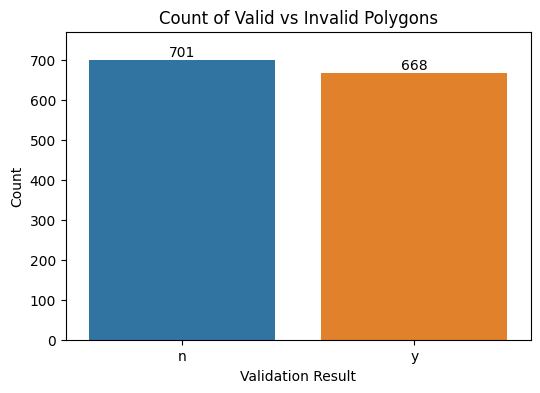

In [19]:
# see bar char count of valid vs invalid and the number in the bar
validation_counts = gdf['validation'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=validation_counts.index, y=validation_counts.values, palette=['tab:blue', 'tab:orange'])
plt.title("Count of Valid vs Invalid Polygons")
plt.xlabel("Validation Result")
plt.ylabel("Count")
for i, count in enumerate(validation_counts.values):
    plt.text(i, count + 1, str(count), ha='center', va='bottom')
plt.ylim(0, validation_counts.values.max() * 1.1)
plt.show()


